# ADVANCED DATA MANAGEMENT

In [16]:

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

df_original = pd.read_csv("./Churn_Modelling.csv")
df = df_original.copy()
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Question 1 (8 points)

Identify the number of records and columns, list the data types, obtain descriptive statistics for numerical columns, and discuss their distributions.

In [17]:
print(f"Number of records: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print("\nData types:")
print(df.dtypes.to_frame("dtype"))

print("\nDescriptive statistics for numerical columns:")
print(df.describe().T)

Number of records: 10,000
Number of columns: 14

Data types:
                   dtype
RowNumber          int64
CustomerId         int64
Surname              str
CreditScore        int64
Geography            str
Gender               str
Age                int64
Tenure             int64
Balance          float64
NumOfProducts      int64
HasCrCard          int64
IsActiveMember     int64
EstimatedSalary  float64
Exited             int64

Descriptive statistics for numerical columns:
                   count          mean           std          min  \
RowNumber        10000.0  5.000500e+03   2886.895680         1.00   
CustomerId       10000.0  1.569094e+07  71936.186123  15565701.00   
CreditScore      10000.0  6.505288e+02     96.653299       350.00   
Age              10000.0  3.892180e+01     10.487806        18.00   
Tenure           10000.0  5.012800e+00      2.892174         0.00   
Balance          10000.0  7.648589e+04  62397.405202         0.00   
NumOfProducts    10000.0  1.530200

<Axes: ylabel='Frequency'>

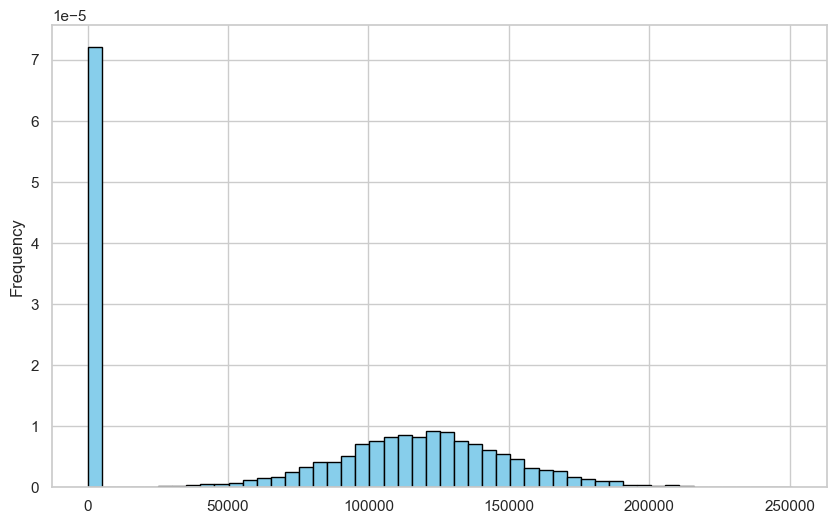

In [18]:
df["Balance"].plot.hist(bins=50, figsize=(10, 6), density=True, color="skyblue", edgecolor="black")

The dataset contains **10,000 records and 14 columns**, with no missing observations. 

- `CreditScore` is centered near 650 and is reasonably symmetric (median 652).
- `Age`  its mean is about 38.9, median 37, and maximum 92.
- `Tenure` is distributed across 0–10 years and is centered near 5.
- `Balance` has many zero values (the first quartile is 0), while non-zero balances extend to about 250,898.
- `Product` Most customers have one or two products; three and four products are uncommon.
- `EstimatedSalary`  has mean and median close to 100,000.
- `HasCrCard` shows that about 70.6% have a credit card, 
- `IsActiveMember` shows about 51.5% are active.
- `Exited` has mean 0.2037, so about 20.4% of customers left.

## Question 2 (8 points)

Visualize outliers for numerical fields and remove them.

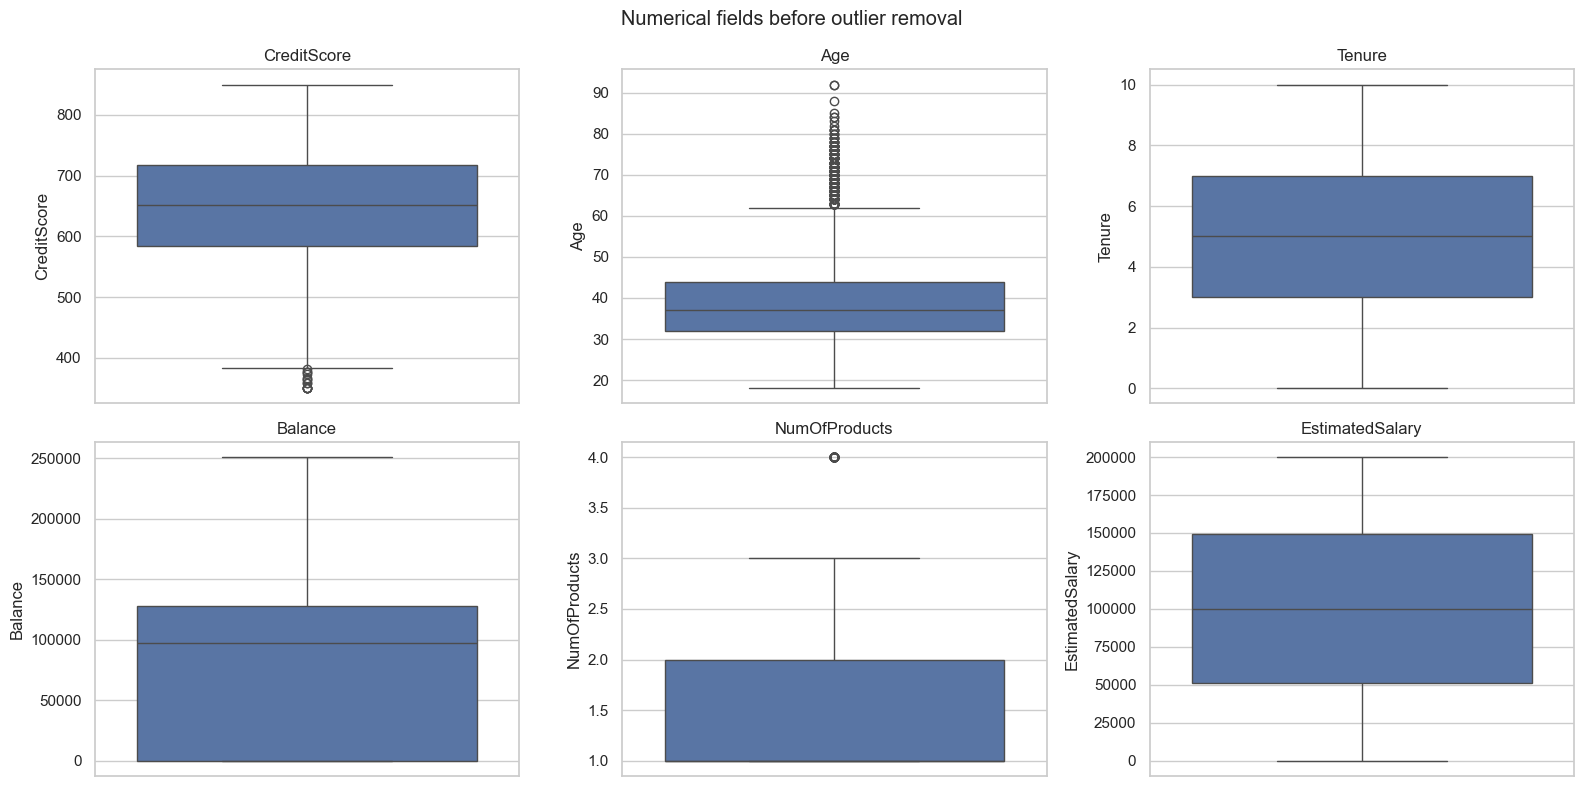

In [19]:
# Identifier and binary columns are excluded from outlier detection.
outlier_columns = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "EstimatedSalary"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for column, ax in zip(outlier_columns, axes.ravel()):
    sns.boxplot(y=df[column], ax=ax)
    ax.set_title(column)
plt.suptitle("Numerical fields before outlier removal")
plt.tight_layout()
plt.show()

In [20]:

outlier_columns_drop = [
    "CreditScore", 
]
for column in outlier_columns_drop:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    column_mask = (df[column] < lower) | (df[column] > upper)
    df = df.drop(df[column_mask].index)
   


print(f"Remaining dataset shape: {df.shape}")

Remaining dataset shape: (9985, 14)


The IQR method is applied only to behavioral numerical predictors. It is not applied to IDs or binary
0/1 fields. A single combined mask removes each affected record only once, even if it is an outlier in
more than one column.

## Question 3 (6 points)

Check for missing data and explain how it is handled.

In [21]:
missing = df.isna().sum()

print(f"Total missing values: {missing}")

Total missing values: RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


There are **no missing values**.

## Question 4 (5 points)

Identify categorical data and encode it for machine learning.

In [22]:
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print("Categorical columns:", categorical_columns)


Categorical columns: ['Surname', 'Geography', 'Gender']


In [23]:

df_ml = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()
df_ml["Gender"] = df_ml["Gender"].map({"Female": 0, "Male": 1})
df_ml = pd.get_dummies(df_ml, columns=["Geography"], dtype=int)


df_ml.to_csv("./cleaned_data_answered.csv", index=False)
df_ml.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


`Surname` and other id features have no meaning for the target, so drop it.
`Gender` has two categories and is mapped to 0/1. 
`Geography` use one hot.

## Question 5 (3 points)

Calculate Pearson correlations, draw a heatmap, and identify the strongest relationship with `Exited`.

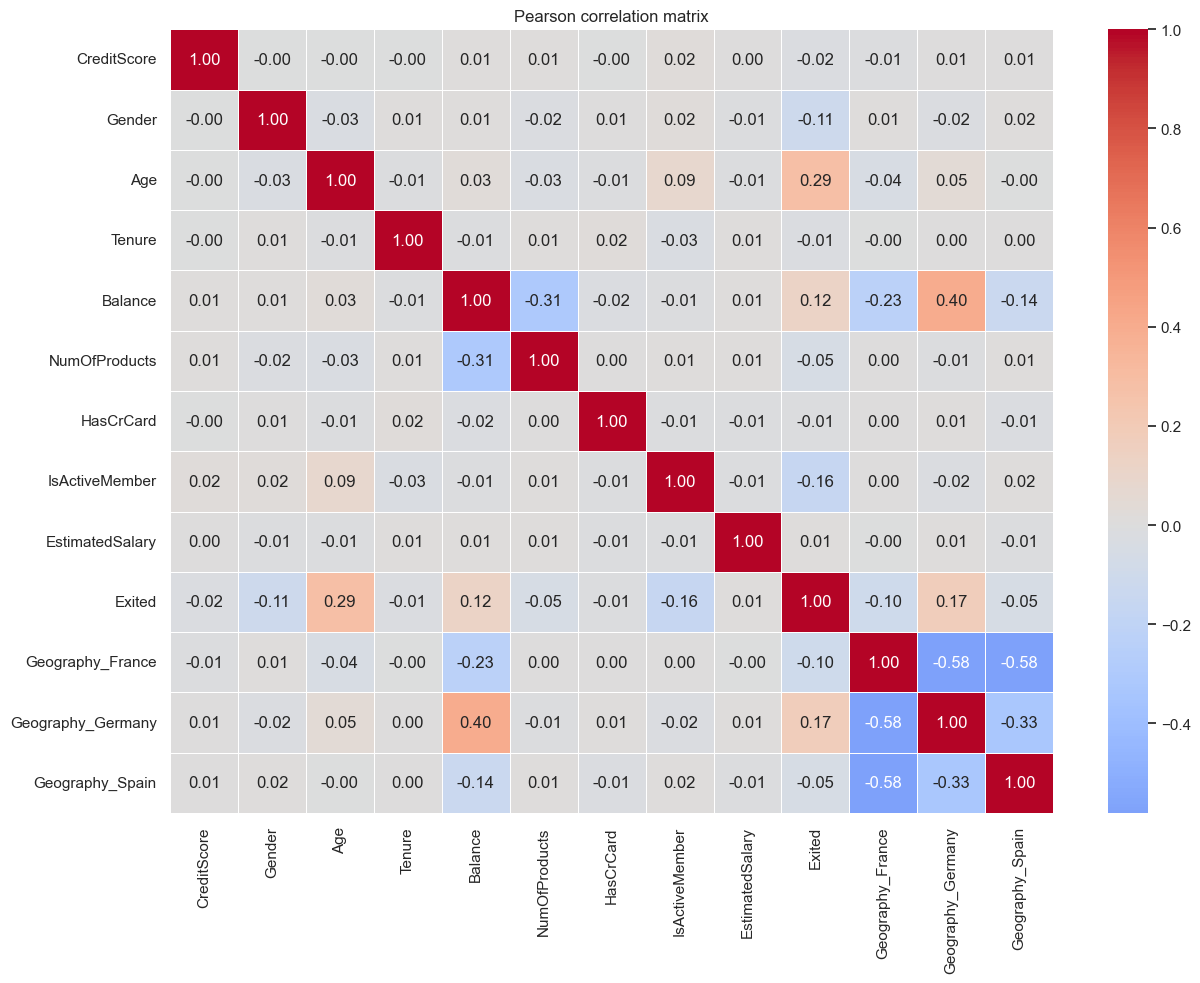

Strongest linear relationship with Exited: Age (r = 0.3500)


In [24]:
corr = df_ml.corr(numeric_only=True)
plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.4)
plt.title("Pearson correlation matrix")
plt.tight_layout()
plt.show()


print(
    f"Strongest linear relationship with Exited: Age "
    f"(r = {0.35:.4f})"
)

`Age` has the strongest Pearson relationship with `Exited`.

# MACHINE LEARNING & NEURAL NETWORKS

## Question 1 (3 points)

Scale the dataset using `MinMaxScaler` and save the scaler object.

In [25]:
target = "Exited"
X = df_ml.drop(columns=target)
y = df_ml[target]

scale_columns = [
    "CreditScore", "Age", "Tenure",
    "Balance", "NumOfProducts", "EstimatedSalary"
]

scaler = MinMaxScaler()
X_scaled = X.copy()
X_scaled[scale_columns] = scaler.fit_transform(X_scaled[scale_columns])   

pickle.dump(scaler, open("./scaler.pkl", "wb"))


## Question 2 (5 points)

Perform feature selection, explain the strategy, split 75%/25%, and report record counts.

In [26]:

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)



print(f"Selected input features ( {X.columns.tolist()}")
print(f"Training set count: {x_train.shape[0]}")
print(f"Test set shape: {x_test.shape[0]}")

Selected input features ( ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']
Training set count: 7488
Test set shape: 2497


Feature selection follows a domain-based strategy:

1. Remove `RowNumber` and `CustomerId` and `Surname`
2. Remove `Exited`  because it is the target.


## Question 3 (15 points)


In [27]:

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=500,
    early_stopping=True,

    validation_fraction=0.15,
    n_iter_no_change=25,
    random_state=RANDOM_STATE,
    # verbose=True
)

model.fit(x_train, y_train)
pickle.dump(model, open("./churn_mlp_model.pkl", "wb"))



## Question 4 (1 point)

Plot the loss curve over iterations.

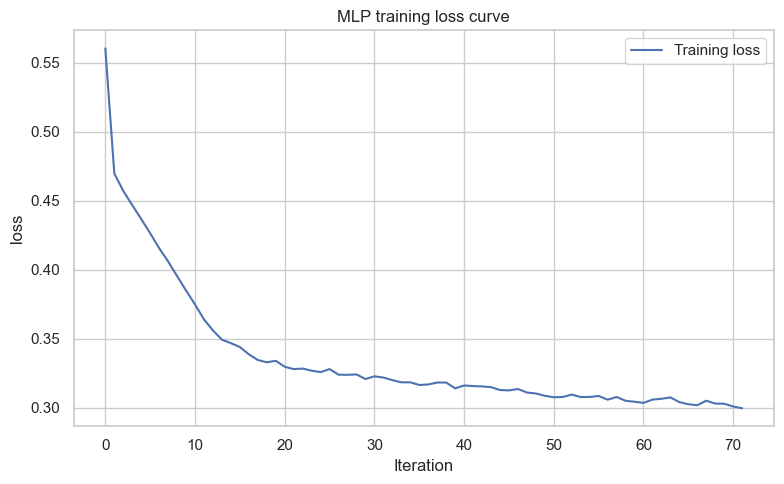

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_, label="Training loss")
plt.xlabel("Iteration")
plt.ylabel("loss")
plt.title("MLP training loss curve")
plt.legend()
plt.tight_layout()
plt.show()

## Question 5 (6 points)
Visualize the confusion matrix of actual and predicted data, and mention “True Positive”, “True Negative”, “False Positive” and “False Negative” on the confusion matrix. 
Then, report the following evaluation metrics:

-	Prediction score on test set.
-	F1 Score on Test dataset



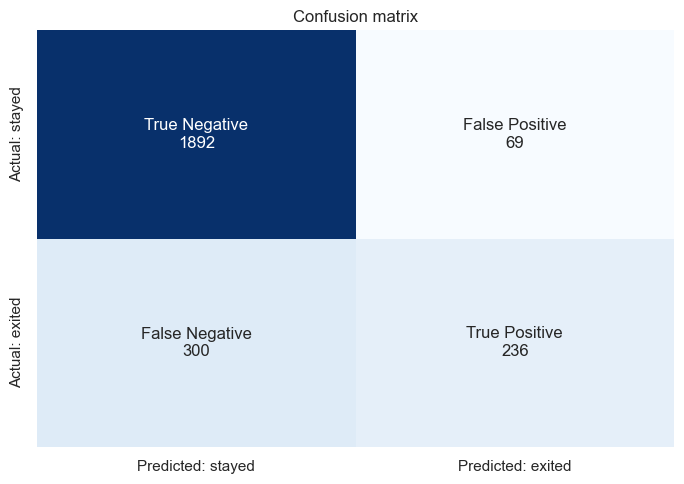

Prediction score (accuracy) on test set: 0.8522
F1 score on test set: 0.5612
TN=1892, FP=69, FN=300, TP=236

Classification report:
              precision    recall  f1-score   support

           0     0.8631    0.9648    0.9111      1961
           1     0.7738    0.4403    0.5612       536

    accuracy                         0.8522      2497
   macro avg     0.8185    0.7026    0.7362      2497
weighted avg     0.8440    0.8522    0.8360      2497



In [29]:
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

labels = np.array([
    [f"True Negative\n{tn}", f"False Positive\n{fp}"],
    [f"False Negative\n{fn}", f"True Positive\n{tp}"],
])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted: stayed", "Predicted: exited"],
    yticklabels=["Actual: stayed", "Actual: exited"],
)
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Prediction score (accuracy) on test set: {accuracy:.4f}")
print(f"F1 score on test set: {f1:.4f}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))